# **Importing Libraries**

In [ ]:
!pip install onnx

In [ ]:
!pip uninstall -y insightface albumentations
!pip install insightface==0.7.3 --no-deps
!pip install onnxruntime
!pip install opencv-python

In [1]:
import warnings
warnings.filterwarnings('ignore')

try:
    import insightface
    from insightface.app import FaceAnalysis
except ImportError as e:
    print(f"Import error: {e}")
    print("Trying alternative import...")

    
    import sys
    import types

   
    dummy_module = types.ModuleType('mask_renderer')
    sys.modules['insightface.app.mask_renderer'] = dummy_module

    import insightface
    from insightface.app import FaceAnalysis

print("Import successful!")

Import error: No module named 'albumentations'
Trying alternative import...
Import successful!


In [ ]:
!pip install --force-reinstall numpy==1.26.4
!pip install --force-reinstall scipy==1.10.1
!pip install --force-reinstall scikit-learn==1.3.2

In [2]:
from insightface.app import FaceAnalysis
from PIL import Image
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
import matplotlib.pyplot as plt
import cv2, os
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings("ignore")

In [3]:
import os, time
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision.transforms as T
import torchvision.models as models
from PIL import Image
import numpy as np
from sklearn.metrics import classification_report, accuracy_score
from tqdm import tqdm

# **Loading Data**

In [ ]:
!pip install kaggle

In [4]:
dataset_path = "/kaggle/input/rvf10k/rvf10k/train"
classes = ["fake", "real"]

In [5]:
for cls in classes:
    cls_path = os.path.join(dataset_path, cls)
    num_images = len([f for f in os.listdir(cls_path) if f.endswith(('.jpg', '.png'))])
    print(f"Number of images in '{cls}': {num_images}")

Number of images in 'fake': 3500
Number of images in 'real': 3500


# **Face Extraction**

In [6]:
def robust_face_detection(image_path):
    img = cv2.imread(image_path)
    if img is None:
        return None

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img_rgb.shape[:2]

    detectors = [
        ("insightface", lambda: insightface_detector(img_rgb)),
        ("opencv_haar", lambda: opencv_haar_detector(img_rgb)),
        ("dlib_hog", lambda: dlib_hog_detector(img_rgb)),
        ("center_crop", lambda: center_crop_fallback(img_rgb)),
        ("multiple_scales", lambda: multi_scale_detection(img_rgb))
    ]

    for detector_name, detector_func in detectors:
        result = detector_func()
        if result is not None:
            return result

    return None

def insightface_detector(img_rgb):
    faces = app.get(img_rgb)
    if len(faces) > 0:
        face = faces[0]
        x1, y1, x2, y2 = face.bbox.astype(int)
        return safe_crop(img_rgb, x1, y1, x2, y2)
    return None

def opencv_haar_detector(img_rgb):
    face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')
    profile_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_profileface.xml')

    gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)

   
    faces = face_cascade.detectMultiScale(gray, 1.1, 4)
    if len(faces) > 0:
        x, y, w, h = faces[0]
        return safe_crop(img_rgb, x, y, x+w, y+h)

    
    faces = profile_cascade.detectMultiScale(gray, 1.1, 4)
    if len(faces) > 0:
        x, y, w, h = faces[0]
        return safe_crop(img_rgb, x, y, x+w, y+h)

    return None

def dlib_hog_detector(img_rgb):
    try:
        import dlib
        detector = dlib.get_frontal_face_detector()
        gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)
        faces = detector(gray, 1)  # Upsample once

        if len(faces) > 0:
            face = faces[0]
            return safe_crop(img_rgb, face.left(), face.top(), face.right(), face.bottom())
    except ImportError:
        pass
    return None

def center_crop_fallback(img_rgb):
    """Fallback for centered faces"""
    h, w = img_rgb.shape[:2]
    crop_size = int(min(h, w) * 0.8)  # 80% of smaller dimension
    y1 = (h - crop_size) // 2
    x1 = (w - crop_size) // 2
    return safe_crop(img_rgb, x1, y1, x1+crop_size, y1+crop_size)

def multi_scale_detection(img_rgb):
    """Try detecting at multiple scales"""
    gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)
    face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')

    for scale in [1.0, 1.2, 1.5, 0.8]:
        scaled_img = cv2.resize(gray, None, fx=scale, fy=scale)
        faces = face_cascade.detectMultiScale(scaled_img, 1.1, 4)

        if len(faces) > 0:
            x, y, w, h = faces[0]
           
            x, y, w, h = int(x/scale), int(y/scale), int(w/scale), int(h/scale)
            return safe_crop(img_rgb, x, y, x+w, y+h)

    return None

def safe_crop(img, x1, y1, x2, y2):
    """Ensure crop coordinates are within image bounds"""
    h, w = img.shape[:2]
    x1, y1 = max(0, x1), max(0, y1)
    x2, y2 = min(w, x2), min(h, y2)

    if x2 <= x1 or y2 <= y1:
        return None

    crop = img[y1:y2, x1:x2]
    if crop.size == 0:
        return None

    return cv2.resize(crop, (299, 299))

In [7]:
app = FaceAnalysis(name="buffalo_l")
app.prepare(ctx_id=0, det_size=(640, 640))

download_path: /root/.insightface/models/buffalo_l


100%|██████████| 281857/281857 [00:02<00:00, 105199.23KB/s]


Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/2d106det.onnx landmark_2d_106 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/det_10g.onnx detection [1, 3, '?', '?'] 127.5 128.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/genderage.onnx genderage ['None', 3, 96, 96] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/w600k_r50.onnx recognition ['None', 3, 112, 112] 127.5 127.5
set det-size: (640, 640)


# **Constants initialization**

In [8]:
# Settings
IMG_SIZE = 299
BATCH_SIZE = 64
NUM_WORKERS = 8
SEED = 42
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

Using device: cuda


In [9]:
torch.manual_seed(SEED)
if DEVICE.type == "cuda":
    torch.cuda.manual_seed_all(SEED)

# **Creating Dataset**

## Dataset Class

In [ ]:
#  Dataset class that uses robust_face_detection() 
class FaceDataset(Dataset):
    def __init__(self, dataset_path, classes, transform=None, preload=False):
        self.samples = []
        self.transform = transform
        for label, cls in enumerate(classes):
            cls_path = os.path.join(dataset_path, cls)
            imgs = [f for f in os.listdir(cls_path) if f.lower().endswith(('.jpg','.jpeg','.png'))]
            for im in imgs:
                self.samples.append((os.path.join(cls_path, im), label))
        self.preload = preload
        if self.preload:
            
            self.cache = []
            for p, lbl in tqdm(self.samples, desc="Preloading faces"):
                face = robust_face_detection(p)
                if face is None:
                    
                    img = cv2.imread(p)
                    if img is None:
                        continue
                    face = cv2.resize(cv2.cvtColor(img, cv2.COLOR_BGR2RGB), (IMG_SIZE, IMG_SIZE))
                self.cache.append((face, lbl))

    def __len__(self):
        return len(self.samples) if not self.preload else len(self.cache)

    def __getitem__(self, idx):
        if self.preload:
            face, label = self.cache[idx]
            img = Image.fromarray(face)
        else:
            path, label = self.samples[idx]
            face = robust_face_detection(path)
            if face is None:
                
                img_bgr = cv2.imread(path)
                if img_bgr is None:
                    
                    face = np.zeros((IMG_SIZE, IMG_SIZE, 3), dtype=np.uint8)
                else:
                    face = cv2.resize(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB), (IMG_SIZE, IMG_SIZE))
            img = Image.fromarray(face)
        if self.transform:
            img = self.transform(img)
        return img, int(label)

## Augmentation for train and validation data

In [ ]:
#  augmentation for train,val 
train_transform = T.Compose([
    T.RandomHorizontalFlip(),
    T.RandomRotation(10),
    T.RandomResizedCrop(IMG_SIZE, scale=(0.8, 1.0)),
    T.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1),
    T.ToTensor(),
    T.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
])

val_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
])

## Dataset & Loaders Initialization

In [ ]:
dataset = FaceDataset(dataset_path, classes, transform=None, preload=False)

labels = [lbl for (_, lbl) in dataset.samples]
from sklearn.model_selection import train_test_split
indices = list(range(len(dataset)))
train_idx, test_idx = train_test_split(indices, test_size=0.2, stratify=labels, random_state=SEED)
train_idx, val_idx = train_test_split(train_idx, test_size=0.15, stratify=[labels[i] for i in train_idx], random_state=SEED)

from torch.utils.data import Subset

train_ds = Subset(FaceDataset(dataset_path, classes, transform=train_transform, preload=False), train_idx)
val_ds   = Subset(FaceDataset(dataset_path, classes, transform=val_transform, preload=False), val_idx)
test_ds  = Subset(FaceDataset(dataset_path, classes, transform=val_transform, preload=False), test_idx)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

print("Sizes -> train:", len(train_ds), "val:", len(val_ds), "test:", len(test_ds))

# **Modeling**

## Loading the model (EfficientNet)

In [ ]:
backbone = models.efficientnet_b0(pretrained=True)

if hasattr(backbone.classifier, "in_features"):
    backbone_out_features = backbone.classifier[1].in_features if isinstance(backbone.classifier, nn.Sequential) else backbone.classifier.in_features
else:
   
    backbone_out_features = 1280

## Replacing model head

In [ ]:
# Replace classifier with Identity (we'll add our own head)
backbone.classifier = nn.Identity()

In [ ]:
# New head
# Improved head with more capacity and better regularization
class Net(nn.Module):
    def __init__(self, backbone, feat_dim):
        super().__init__()
        self.backbone = backbone
        self.head = nn.Sequential(
            nn.Dropout(0.5),  # Increased dropout
            nn.Linear(feat_dim, 512),
            nn.LeakyReLU(0.1, inplace=True),  # Better than ReLU
            nn.BatchNorm1d(512),
            nn.Dropout(0.4),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.1, inplace=True),
            nn.BatchNorm1d(256),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.LeakyReLU(0.1, inplace=True),
            nn.Dropout(0.2),
            nn.Linear(128, 1)
        )

    def forward(self, x):
        feats = self.backbone(x)
        if feats.ndim == 4:
            feats = torch.flatten(feats, 1)
        return self.head(feats).squeeze(1)

model = Net(backbone, backbone_out_features).to(DEVICE)

## Helper Functions

In [ ]:
def train_one_epoch(loader, model, criterion, optimizer, device, scaler):
    model.train()
    running_loss = 0.0

    for imgs, labels in loader:
        imgs = imgs.to(device, non_blocking=True)
        labels = labels.float().to(device, non_blocking=True)

        optimizer.zero_grad()

        # ---- Mixed Precision Forward ----
        with autocast():
            logits = model(imgs)
            loss = criterion(logits, labels)

        # ---- Scaled Backward ----
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item() * imgs.size(0)

    return running_loss / len(loader.dataset)

In [ ]:
def evaluate(loader, model, device):
    model.eval()
    preds = []
    trues = []
    losses = []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(device, non_blocking=True)
            labels = labels.float().to(device, non_blocking=True)
            logits = model(imgs)
            loss = criterion(logits, labels)
            probs = torch.sigmoid(logits).cpu().numpy()
            batch_preds = (probs >= 0.5).astype(int)
            preds.extend(batch_preds.tolist())
            trues.extend(labels.cpu().numpy().astype(int).tolist())
            losses.append(loss.item() * imgs.size(0))
    avg_loss = sum(losses) / len(loader.dataset)
    return avg_loss, np.array(trues), np.array(preds), np.array(probs)

## Loss, Optimizer & Scheduler

In [ ]:
criterion = nn.BCEWithLogitsLoss()


optimizer = optim.AdamW(  
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=2e-4,  # Lower initial LR
    weight_decay=1e-4,  # Slightly higher regularization
    betas=(0.9, 0.999)
)

scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer, T_0=10, T_mult=2, eta_min=1e-7
)

## Phase 1 (Head Training)

In [ ]:
# freeze backbone
for param in model.backbone.parameters():
    param.requires_grad = False

In [ ]:
from torch.cuda.amp import autocast, GradScaler
scaler = torch.cuda.amp.GradScaler()

In [ ]:
import cv2
cv2.ocl.setUseOpenCL(False)

In [ ]:
# --- Phase 1: Train head only ---
EPOCHS_PHASE1 = 12
best_val_loss = 1e9
patience_counter = 0
EARLY_STOP = 6

for epoch in range(1, EPOCHS_PHASE1 + 1):
    t0 = time.time()
    train_loss = train_one_epoch(train_loader, model, criterion, optimizer, DEVICE)
    val_loss, y_val_true, y_val_pred, y_val_prob = evaluate(val_loader, model, DEVICE)
    scheduler.step(val_loss)
    t1 = time.time()
    print(f"Phase1 Epoch {epoch}/{EPOCHS_PHASE1} - train_loss: {train_loss:.4f} val_loss: {val_loss:.4f} time: {t1-t0:.1f}s")
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), "best_phase1.pt")
        patience_counter = 0
    else:
        patience_counter += 1
    if patience_counter >= EARLY_STOP:
        print("Early stopping phase 1")
        break

In [ ]:
# Load best phase1 weights
model.load_state_dict(torch.load("best_phase1.pt"))

## Phase 2 (Backbone unfreezing and finetuning)

In [ ]:
# --- Phase 2: Unfreeze top layers of backbone and fine-tune ---
# Unfreeze last ~15% of backbone layers
total_layers = len(list(model.backbone.features))
unfreeze_from = int(total_layers * 0.85)
print("Unfreezing backbone layers from index", unfreeze_from, "of", total_layers)
for idx, layer in enumerate(model.backbone.features):
    requires = True if idx >= unfreeze_from else False
    for p in layer.parameters():
        p.requires_grad = requires

In [ ]:
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=5e-5, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer, T_0=6, T_mult=2, eta_min=1e-6
)

In [ ]:
EPOCHS_PHASE2 = 45
best_val_loss = 1e9
patience_counter = 0
EARLY_STOP = 7

for epoch in range(1, EPOCHS_PHASE2 + 1):
    t0 = time.time()
    train_loss = train_one_epoch(train_loader, model, criterion, optimizer, DEVICE, scaler)
    val_loss, y_val_true, y_val_pred, y_val_prob = evaluate(val_loader, model, DEVICE)
    scheduler.step(epoch)
    t1 = time.time()
    print(f"Phase2 Epoch {epoch}/{EPOCHS_PHASE2} - train_loss: {train_loss:.4f} val_loss: {val_loss:.4f} time: {t1-t0:.1f}s")
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), "best_phase2.pt")
        patience_counter = 0
    else:
        patience_counter += 1
    if patience_counter >= EARLY_STOP:
        print("Early stopping phase 2")
        break

In [ ]:
# Load best final weights
model.load_state_dict(torch.load("best_phase2.pt"))

## Final Model Evaluation

In [ ]:
#  Final evaluation on test data 
test_loss, y_test_true, y_test_pred, y_test_prob = evaluate(test_loader, model, DEVICE)
print("Test loss:", test_loss)
print("Accuracy:", accuracy_score(y_test_true, y_test_pred))
print(classification_report(y_test_true, y_test_pred, target_names=classes))

In [ ]:
torch.save(model.state_dict(), "final_model.pt")
print("Saved final_model.pt")

# XAI : GradCam

In [40]:
import torch
import torch.nn.functional as F
from torchvision import transforms, models
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import torch.nn as nn

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


model = models.efficientnet_b0(weights=None)
model.classifier[1] = nn.Linear(1280, 1)

state_dict = torch.load("/kaggle/input/final-weight/new_best_phase2 (2).pt", map_location=device)
state_dict.pop('classifier.1.weight', None)
state_dict.pop('classifier.1.bias', None)
model.load_state_dict(state_dict, strict=False)

model = model.to(device)
model.eval()


gradients = []
activations = []

def save_gradient(module, grad_in, grad_out):
    gradients.append(grad_out[0])

def save_activation(module, input, output):
    activations.append(output)

target_layer = model.features[-1]
target_layer.register_forward_hook(save_activation)
target_layer.register_backward_hook(save_gradient)


transform = transforms.Compose([
    transforms.Resize((229, 229)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

def generate_cam(img_path):
    """
    Input: path to image
    Uses robust_face_detection internally
    """
    face = robust_face_detection(img_path)  
    if face is None:
        print("Face not detected!")
        return

    img = Image.fromarray(face)  
    input_tensor = transform(img).unsqueeze(0).to(device)

    # Forward
    output = model(input_tensor)
    score = output.squeeze()

    # Backward
    model.zero_grad()
    score.backward()
    # convert logit → probability
    prob = torch.sigmoid(score).item()     
    pred_class = "real" if prob >= 0.5 else "fake"
    
    print("Predicted class:", pred_class)
    print("Probability:", prob)
    # Collect
    grads = gradients[-1].detach()
    acts = activations[-1].detach()

    # GAP weights
    weights = grads.mean(dim=(2, 3), keepdim=True)

    # Weighted sum
    cam = (weights * acts).sum(dim=1).squeeze()

    # Normalize
    cam = F.relu(cam)
    cam = cam - cam.min()
    cam = cam / cam.max()
    cam = cam.cpu().numpy()

    # Resize to image size
    cam = np.uint8(255 * cam)
    cam = Image.fromarray(cam).resize(img.size, Image.BILINEAR)

    # Visualization
    plt.figure(figsize=(6,6))
    plt.imshow(img)
    plt.imshow(cam, cmap='jet', alpha=0.4)
    plt.axis('off')
    plt.show()





Predicted class: fake
Probability: 0.49544188380241394


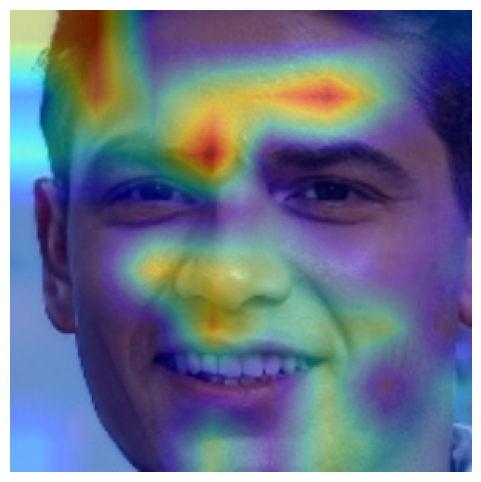

In [41]:
generate_cam("/kaggle/input/rvf10k/rvf10k/train/fake/024SZKKV3S.jpg") # fake

# XAI : Lime

In [27]:
import numpy as np
import torch
import cv2
from PIL import Image
import matplotlib.pyplot as plt
from lime import lime_image
from skimage.segmentation import mark_boundaries
from torchvision import transforms, models
import torch.nn as nn



device = torch.device("cuda" if torch.cuda.is_available() else "cpu")




model = models.efficientnet_b0(weights=None)
model.classifier[1] = nn.Linear(1280, 1)

state = torch.load("/kaggle/input/final-weight/new_best_phase2 (2).pt", map_location=device)
state.pop("classifier.1.weight", None)
state.pop("classifier.1.bias", None)
model.load_state_dict(state, strict=False)

model = model.to(device)
model.eval()




transform = transforms.Compose([
    transforms.Resize((229, 229)), 
    transforms.ToTensor(), 
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])






def preprocess_lime_image(img_np):
    """
    LIME gives numpy float image → convert to correct format
    """
    if img_np.dtype != np.uint8:
        img_np = (img_np * 255).astype(np.uint8)

    pil = Image.fromarray(img_np)
    tensor = transform(pil)
    return tensor



# ======================================================
# 5) Prediction function required by LIME
# ======================================================
def predict_fn(images):
    """
    images = list of numpy arrays generated by LIME
    output = probabilities (fake, real)
    """
    batch = []

    for img_np in images:
        tensor = preprocess_lime_image(img_np)
        batch.append(tensor.unsqueeze(0))

    batch = torch.cat(batch).to(device)

    with torch.no_grad():
        logits = model(batch)
        probs = torch.sigmoid(logits).cpu().numpy() 

    return np.concatenate([1 - probs, probs], axis=1)



# ======================================================
# 6) LIME wrapper with robust_face_detection
# ======================================================
explainer = lime_image.LimeImageExplainer()


def lime_explain(img_path):
    """
    1) Run robust_face_detection
    2) Pass cropped face to LIME
    """


    face = robust_face_detection(img_path)

    if face is None:
        raise ValueError("No face detected by robust_face_detection.")

    # Convert for LIME: LIME expects uint8 image
    face = face.astype(np.uint8)

    explanation = explainer.explain_instance(
        face,
        classifier_fn=predict_fn,
        top_labels=1,
        num_samples=5000
    )

    label = explanation.top_labels[0]
    print(label)
    label_text = "fake" if label == 0 else "real"
    print(label_text)

    temp, mask = explanation.get_image_and_mask(
        label,
        positive_only=True,
        num_features=8,
        hide_rest=False
    )

    plt.figure(figsize=(6,6))
    plt.imshow(mark_boundaries(temp, mask))
    plt.axis("off")
    plt.show()

    return explanation


  0%|          | 0/5000 [00:00<?, ?it/s]

0
fake


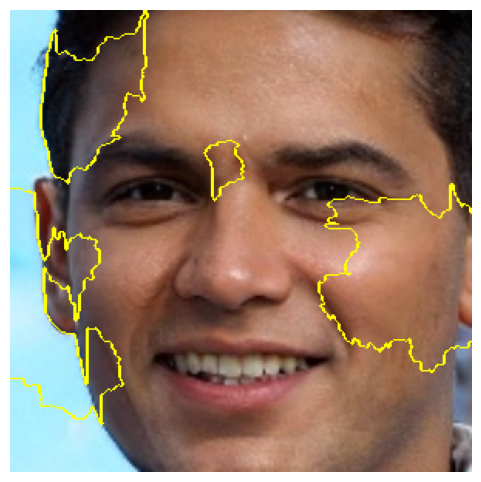

In [42]:

lime_explain("/kaggle/input/rvf10k/rvf10k/train/fake/024SZKKV3S.jpg") # fake